# 01 — Steering Profiles $U(\theta)$ and $V(\theta)$

Build geometric intuition: scan $(\theta, \delta)$ heatmaps, watch a single well split into a double well as $\delta$ crosses the pitchfork, and overlay Duffing on Bessel to mark where the cubic approximation breaks down.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from steering.params import ModelParams, ForcingParams
from steering.models import (
    DuffingModel,
    BesselSteeringModel,
    ContinuousPFLModel,
    DiscretePFLModel,
    FullCircuitModel,
)
from steering.dynamics import VelocityDynamics, AccelerationDynamics
from steering.integrator import Simulation
from steering.visualization.style import use_paper_style

use_paper_style()


## $U(\theta, \delta)$ heatmap (Bessel)

Fix $\kappa = 2$ and scan $(\theta, \delta)$ on a grid. The zero contours of this heatmap *are* the fixed-point branches as $\delta$ varies — a direct visualisation of the pitchfork.

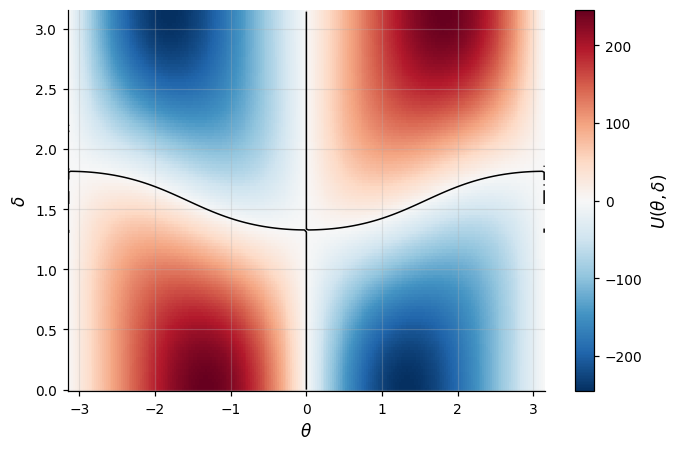

In [4]:
kappa = 2.0
thetas = np.linspace(-np.pi, np.pi, 251)
deltas = np.linspace(0.0, np.pi, 121)
U = np.empty((deltas.size, thetas.size))
bessel = BesselSteeringModel()
for i, d in enumerate(deltas):
    p = ModelParams(kappa_h=kappa, kappa_g=kappa, delta=d)
    U[i] = bessel.steering_drive(thetas, p)
fig, ax = plt.subplots(figsize=(7, 4.5))
mesh = ax.pcolormesh(thetas, deltas, U, cmap='RdBu_r', shading='auto', vmin=-np.max(np.abs(U)), vmax=np.max(np.abs(U)))
ax.contour(thetas, deltas, U, levels=[0.0], colors='k', linewidths=1.0)
ax.set_xlabel(r'$\theta$'); ax.set_ylabel(r'$\delta$')
fig.colorbar(mesh, ax=ax, label=r'$U(\theta,\delta)$')
plt.show()


## $V(\theta)$ cross-sections through the pitchfork

Pick a few $\delta$ values: below, at, above the bifurcation. Watch the single well split into two.

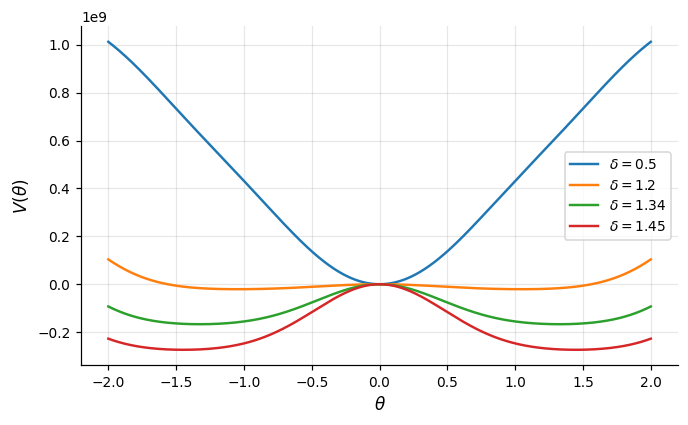

In [13]:
chosen = [0.5, 1.20, 1.34, 1.45]
thetas = np.linspace(-2.0, 2.0, 401)
fig, ax = plt.subplots(figsize=(7, 4))
for d in chosen:
    p = ModelParams(kappa_h=10.0, kappa_g=10.0, delta=d)
    V = bessel.steering_potential(thetas, p)
    ax.plot(thetas, V, label=fr'$\delta={d}$')
ax.set_xlabel(r'$\theta$'); ax.set_ylabel(r'$V(\theta)$')
ax.legend(); plt.show()


## Bessel vs Duffing overlay

On each cross-section, overlay the Duffing cubic. The error grows with $|\theta|$ — quantify the relative L^infinity error in a band around the origin.

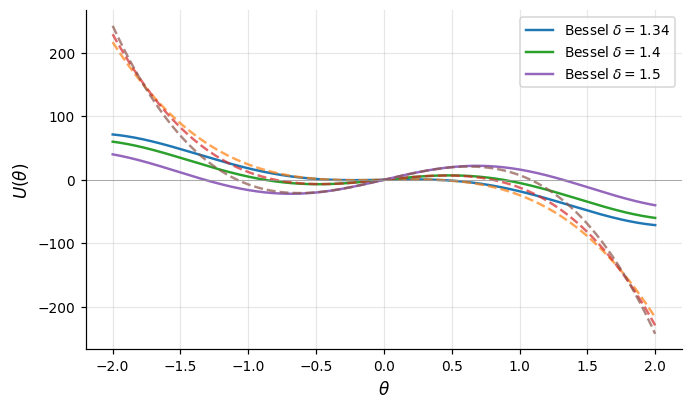

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
for d in [1.34, 1.40, 1.50]:
    p = ModelParams(kappa_h=2.0, kappa_g=2.0, delta=d)
    duff = DuffingModel.from_params(p)
    Ub = bessel.steering_drive(thetas, p)
    Ud = duff.steering_drive(thetas)
    ax.plot(thetas, Ub, label=fr'Bessel $\delta={d}$')
    ax.plot(thetas, Ud, ls='--', alpha=0.7)
ax.axhline(0, color='0.6', lw=0.5)
ax.set_xlabel(r'$\theta$'); ax.set_ylabel(r'$U(\theta)$')
ax.legend(); plt.show()


## Sharpening bumps: $\kappa$ at fixed $\delta$

Higher $\kappa$ deepens and narrows the wells. Verify by plotting $V(\theta)$ for several $\kappa$ values.

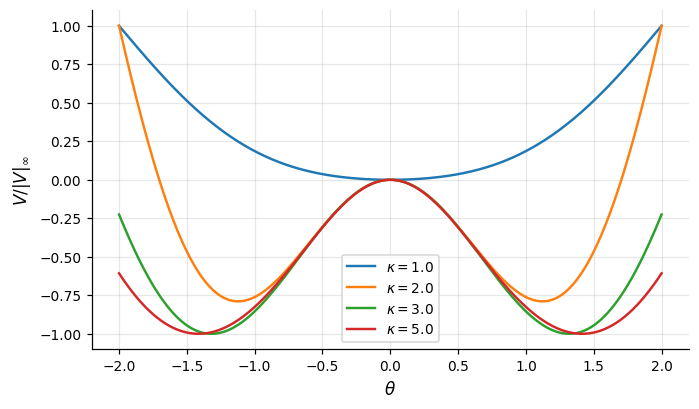

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
for kappa in [1.0, 2.0, 3.0, 5.0]:
    p = ModelParams(kappa_h=kappa, kappa_g=kappa, delta=1.45)
    V = bessel.steering_potential(thetas, p)
    ax.plot(thetas, V / np.max(np.abs(V) + 1e-12), label=fr'$\kappa={kappa}$')
ax.set_xlabel(r'$\theta$'); ax.set_ylabel(r'$V/|V|_\infty$')
ax.legend(); plt.show()
